In [187]:
import pandas as pd
dados=pd.read_json ('/content/TelecomX_Data.json')
dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [188]:
dados.columns #conhecer quais são as colunas do meu DataFrame

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [189]:
dados.info() #detalhes do meu DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [190]:
df_customer_normalizado = pd.json_normalize(dados['customer']) # Normalizar a coluna 'customer' para um DataFrame temporário.
# A função pd.json_normalize() "achata" os dicionários na coluna 'customer'
# criando um novo DataFrame com as chaves do dicionário como colunas.

In [191]:
for col in df_customer_normalizado.columns:
    dados[col] = df_customer_normalizado[col] #Atribuir as novas colunas do DataFrame normalizado diretamente ao 'dados'.
# Isso adiciona as cololas (ex: 'gender', 'SeniorCitizen') do df_customer_normalized
# ao seu DataFrame principal 'dados'. O loop garante que todas as novas colunas sejam transferidas.

In [192]:
dados = dados.drop(columns=['customer']) # Removendo a coluna costumer original, pois não faz mais sentido tê-la

In [193]:
dados.head()

,customerID,Churn,phone,internet,account,gender,SeniorCitizen,Partner,Dependents,tenure
0,0002-ORFBO,No,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9
1,0003-MKNFE,No,"{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9
2,0004-TLHLJ,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4
3,0011-IGKFF,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13
4,0013-EXCHZ,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3


In [194]:
dados.info() # Conferindo se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7267 non-null   object
 1   Churn          7267 non-null   object
 2   phone          7267 non-null   object
 3   internet       7267 non-null   object
 4   account        7267 non-null   object
 5   gender         7267 non-null   object
 6   SeniorCitizen  7267 non-null   int64 
 7   Partner        7267 non-null   object
 8   Dependents     7267 non-null   object
 9   tenure         7267 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 567.9+ KB


In [195]:
df_phone_normalizado = pd.json_normalize(dados['phone']) #Normalizar a coluna 'phone' para um DataFrame temporário.Esta função "achata" os dicionários na coluna 'phone' em um novo DataFrame.


In [196]:
for col in df_phone_normalizado.columns:
    dados[col] = df_phone_normalizado[col]#Atribuir as novas colunas do DataFrame normalizado diretamente ao 'dados'.Isso adiciona as colunas (ex: 'PhoneService', 'MultipleLines') do df_phone_normalized

In [197]:
dados = dados.drop(columns=['phone']) # Remover a coluna phone, uma vez que os dados aninhados já estão no dataframe essa coluna não faz mais sentido

In [198]:
dados.head()

,customerID,Churn,internet,account,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines
0,0002-ORFBO,No,"{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9,Yes,No
1,0003-MKNFE,No,"{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9,Yes,Yes
2,0004-TLHLJ,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4,Yes,No
3,0011-IGKFF,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13,Yes,No
4,0013-EXCHZ,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3,Yes,No


In [199]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7267 non-null   object
 1   Churn          7267 non-null   object
 2   internet       7267 non-null   object
 3   account        7267 non-null   object
 4   gender         7267 non-null   object
 5   SeniorCitizen  7267 non-null   int64 
 6   Partner        7267 non-null   object
 7   Dependents     7267 non-null   object
 8   tenure         7267 non-null   int64 
 9   PhoneService   7267 non-null   object
 10  MultipleLines  7267 non-null   object
dtypes: int64(2), object(9)
memory usage: 624.6+ KB


In [200]:
df_internet_normalizado = pd.json_normalize(dados['internet']) #Vamos normalizar a coluna Internet e colocar as colunas aninhadas em um novo DataFrame

In [201]:
for col in df_internet_normalizado.columns:   #Vamos atribuir as colunas aninhadas no DataFrame principal: dados
    dados[col] = df_internet_normalizado[col]

In [202]:
dados = dados.drop(columns=['internet']) #Vamos remover a coluna internet original do DataFrame

In [203]:
dados.head()


,customerID,Churn,account,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,No,"{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No
1,0003-MKNFE,No,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes
2,0004-TLHLJ,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No
3,0011-IGKFF,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No


In [204]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   account           7267 non-null   object
 3   gender            7267 non-null   object
 4   SeniorCitizen     7267 non-null   int64 
 5   Partner           7267 non-null   object
 6   Dependents        7267 non-null   object
 7   tenure            7267 non-null   int64 
 8   PhoneService      7267 non-null   object
 9   MultipleLines     7267 non-null   object
 10  InternetService   7267 non-null   object
 11  OnlineSecurity    7267 non-null   object
 12  OnlineBackup      7267 non-null   object
 13  DeviceProtection  7267 non-null   object
 14  TechSupport       7267 non-null   object
 15  StreamingTV       7267 non-null   object
 16  StreamingMovies   7267 non-null   object
dtypes: int64(2), o

In [205]:
df_account_normalizado = pd.json_normalize(dados['account']) #Normalização da coluna account para acessar as colunas aninhadas a ela em um novo DataFrame

In [206]:
for col in df_account_normalizado.columns:
    dados[col] = df_account_normalizado[col]  #Atribuir as novas colunas que estavam aninhadas do DataFrame normalizado diretamente ao 'dados'

In [207]:
dados = dados.drop(columns=['account']) #Como já normalizamos a coluna e extraímos as colunas aninhadas, já podemos excluir a coluna account do DataFrame dados

In [208]:
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [209]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [210]:
import numpy as np # Importa a biblioteca numpy, necessária para np.nan

In [211]:
dados['Charges.Total'].dtype # Tipo atual da coluna Charges.Total

dtype('O')

In [212]:
dados['Charges.Total'].head()

,Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4


In [213]:
dados['Charges.Total'] = pd.to_numeric(dados['Charges.Total'], errors='coerce') #Converte a coluna 'TotalCharges' para tipo numérico (float64). Se tiver uma valor que não possa ser convertido ele será mudado para NaN

In [214]:
dados['Charges.Total'].dtype #Novo tipo de dados da coluna Chargestotal

dtype('float64')

In [215]:
dados['Charges.Total'].head()

,Charges.Total
0,593.30
1,542.40
2,280.85
3,1237.85
4,267.40


In [216]:
dados['Charges.Total'].isnull().sum() # Conta quantos valores NaN (nulos) existem agora. Pela saída existem 11 valores NaN

np.int64(11)

In [217]:
dados['Charges.Total'] = dados['Charges.Total'].fillna(0) #Preenche os valores Nan com 0


In [218]:
object_colunas_final = dados.select_dtypes(include='object').columns # Colunas do tipo 'object' após todas as normalizações

In [219]:
print(f"Colunas do tipo 'object' remanescentes: {list(object_colunas_final)}")

Colunas do tipo 'object' remanescentes: ['customerID', 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [220]:
print("\n--- Valores Únicos para as Principais Colunas Categóricas (Object) ---")


--- Valores Únicos para as Principais Colunas Categóricas (Object) ---


In [221]:
colunas_ver_valores= [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn', 'customerID' # customerID é identificador, Churn é alvo.
]

In [222]:
for col in colunas_ver_valores:
    if col in dados.columns: # Garante que a coluna existe no DataFrame
        print(f"\nValores únicos da coluna '{col}':")
        print(dados[col].unique())


Valores únicos da coluna 'gender':
['Female' 'Male']

Valores únicos da coluna 'Partner':
['Yes' 'No']

Valores únicos da coluna 'Dependents':
['Yes' 'No']

Valores únicos da coluna 'PhoneService':
['Yes' 'No']

Valores únicos da coluna 'MultipleLines':
['No' 'Yes' 'No phone service']

Valores únicos da coluna 'InternetService':
['DSL' 'Fiber optic' 'No']

Valores únicos da coluna 'OnlineSecurity':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'OnlineBackup':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'DeviceProtection':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'TechSupport':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'StreamingTV':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'StreamingMovies':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'Contract':
['One year' 'Month-to-month' 'Two year']

Valores únicos da coluna 'PaperlessBilling':
['Yes' 'No']

Valores únicos da coluna 'Payment

In [223]:
print(f"Valores únicos de 'Churn' antes: {dados['Churn'].unique()}") #Saber quais os valores da coluna churn antes do tratamento

Valores únicos de 'Churn' antes: ['No' 'Yes' '']


In [224]:
dados['Churn'] = dados['Churn'].replace('', 'No') #Substituindo valores vazios por No

In [225]:
converte_colunas_binario = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]
#Lista das colunas que queremos converter de 'Yes'/'No' para 1/0, ou seja binária

In [226]:
for col in converte_colunas_binario:
    if col in dados.columns: # Garante que a coluna existe
        # Mapeia 'Yes' para 1 e 'No' para 0
        dados[col] = dados[col].map({'Yes': 1, 'No': 0})
        print(f"Coluna '{col}' convertida. Novos valores únicos: {dados[col].unique()}")
        print(f"Novo dtype de '{col}': {dados[col].dtype}")

Coluna 'Partner' convertida. Novos valores únicos: [1 0]
Novo dtype de 'Partner': int64
Coluna 'Dependents' convertida. Novos valores únicos: [1 0]
Novo dtype de 'Dependents': int64
Coluna 'PhoneService' convertida. Novos valores únicos: [1 0]
Novo dtype de 'PhoneService': int64
Coluna 'PaperlessBilling' convertida. Novos valores únicos: [1 0]
Novo dtype de 'PaperlessBilling': int64
Coluna 'Churn' convertida. Novos valores únicos: [0 1]
Novo dtype de 'Churn': int64


In [227]:
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


In [228]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [229]:
dados['Contas_Diarias'] = dados['Charges.Monthly'] / 30 # Criação da coluna Contas Diarias que será obtida pelo valor da Charges.Monthly/30

In [230]:
dados.head() #Verificar se incluiu a coluna Contas Diarias

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [231]:
colunas_a_padronizar = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]# colunas que podem conter Yes/No no lugar de O ou 1

In [232]:
for col in colunas_a_padronizar:
    if col in dados.columns:
        # Substitui 'No phone service' e 'No internet service' por 'No'
        dados[col] = dados[col].replace(['No phone service', 'No internet service'], 'No')

In [233]:
colunas_mapear = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
] #Vamos listar as colunas 'object' que ainda restam (excluindo customerID) e mapear todas para números

In [234]:
for col in colunas_mapear:
    if col in dados.columns:
        # Pega todos os valores únicos da coluna
        valores_unicos = dados[col].unique()
        # Cria um dicionário de mapeamento: cada valor único para um número sequencial (0, 1, 2...)
        # Ex: {'Male': 0, 'Female': 1} ou {'No': 0, 'Yes': 1} ou {'DSL': 0, 'Fiber optic': 1, 'No': 2}
        mapa_dict = {value: i for i, value in enumerate(valores_unicos)}

        # Aplica o mapeamento na coluna
        dados[col] = dados[col].map(mapa_dict)

        # Converte para int64 para garantir o tipo numérico
        dados[col] = dados[col].astype(np.int64)

        print(f"Coluna '{col}' mapeada. Valores únicos agora: {dados[col].unique()}")
        print(f"Novo dtype de '{col}': {dados[col].dtype}")

print("\n--- Verificando o DataFrame Após Todas as Conversões ---")

Coluna 'gender' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'gender': int64
Coluna 'MultipleLines' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'MultipleLines': int64
Coluna 'InternetService' mapeada. Valores únicos agora: [0 1 2]
Novo dtype de 'InternetService': int64
Coluna 'OnlineSecurity' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'OnlineSecurity': int64
Coluna 'OnlineBackup' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'OnlineBackup': int64
Coluna 'DeviceProtection' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'DeviceProtection': int64
Coluna 'TechSupport' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'TechSupport': int64
Coluna 'StreamingTV' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'StreamingTV': int64
Coluna 'StreamingMovies' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'StreamingMovies': int64
Coluna 'Contract' mapeada. Valores únicos agora: [0 1 2]
Novo dtype de 'Contract': int64
Coluna 'PaymentMethod' mapeada. Valores únic

In [235]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   int64  
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   int64  


Vamos Iniciar a Análise Descritiva

In [236]:
colunas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias'] # Cria um DataFrame com as colunas que tem linhas numéricas int64 e float 64


In [237]:
dados[colunas_numericas].describe() # Usamos describe() para obter estatísticas resumidas para colunas numéricas

,tenure,Charges.Monthly,Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157337
std,24.571773,30.129572,2268.648587,1.004319
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.425000,396.200000,1.180833
50%,29.000000,70.300000,1389.200000,2.343333
75%,55.000000,89.875000,3778.525000,2.995833
max,72.000000,118.750000,8684.800000,3.958333


In [238]:
colunas_categoricas = ['gender', 'Contract', 'PhoneService', 'TechSupport'] # Cria um DataFrame com as colunas categóricas
dados['Churn'].value_counts(normalize=True) # Usamos value_counts(normalize=True) para ver a proporção de cada categoria

,proportion
Churn,
0,0.74281
1,0.25719


In [239]:
for col in colunas_categoricas:
    if col in dados.columns: # Garante que a coluna existe
        print(f"\nDistribuição de '{col}':")
        # Mostra a proporção de cada categoria para as colunas categóricas
        print(dados[col].value_counts(normalize=True))


Distribuição de 'gender':
gender
1    0.505711
0    0.494289
Name: proportion, dtype: float64

Distribuição de 'Contract':
Contract
1    0.551122
2    0.239851
0    0.209027
Name: proportion, dtype: float64

Distribuição de 'PhoneService':
PhoneService
1    0.902711
0    0.097289
Name: proportion, dtype: float64

Distribuição de 'TechSupport':
TechSupport
1    0.710472
0    0.289528
Name: proportion, dtype: float64


"Neste passo, o objetivo é entender como a variável "churn" (evasão) está distribuída entre os clientes. Utilize gráficos para visualizar a proporção de clientes que permaneceram e os que saíram."

In [240]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [241]:
# Calculando as contagens e proporções
qtd_churn = dados['Churn'].value_counts() # Conta o número de churn
proporcao_churn = dados['Churn'].value_counts(normalize=True) * 100 # Calcula a proporção de churn

In [242]:
df_churn = pd.DataFrame({'Count': qtd_churn, 'Proportion (%)': proporcao_churn}) # Cria um DataFrame para a contagem e proporção
df_churn.index = ['Não Churn (0)', 'Churn (1)'] # Renomeando os índices para clareza


In [243]:
df_churn.head()


,Count,Proportion (%)
Não Churn (0),5398,74.280996
Churn (1),1869,25.719004


Gerando Gráfico de Barras

<ipython-input-244-be307a4654d7>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_churn.index, y='Proportion (%)', data=df_churn, palette='viridis', ax=ax)


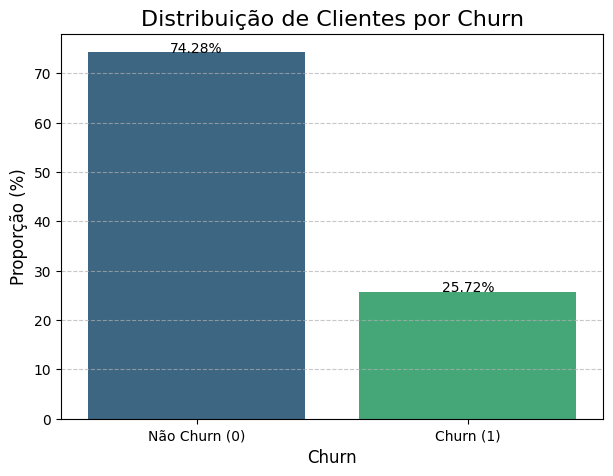

In [244]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=df_churn.index, y='Proportion (%)', data=df_churn, palette='viridis', ax=ax)

# Adicionando os valores percentuais nas barras
for index, row in df_churn.iterrows(): #inicia um loop que percorre cada linha do DataFrame churn_df, atribuindo o rótulo da linha (o índice) à variável index e os dados da linha (como uma Series) à variável row a cada iteração.
    ax.text(index, row['Proportion (%)'], f"{row['Proportion (%)']:.2f}%", color='black', ha="center")
ax.set_title('Distribuição de Clientes por Churn', fontsize=16)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Proporção (%)', fontsize=12)
ax.tick_params(axis='x', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo X
ax.tick_params(axis='y', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo Y
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Criando boxplot para análise de colunas x churn

<ipython-input-245-dccc91df6f90>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)
<ipython-input-245-dccc91df6f90>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  current_ax.set_xticklabels(['Não Churn', 'Churn'], fontsize=12) # Rótulos claros para 0 e 1 do Churn
<ipython-input-245-dccc91df6f90>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)
<ipython-input-245-dccc91df6f90>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

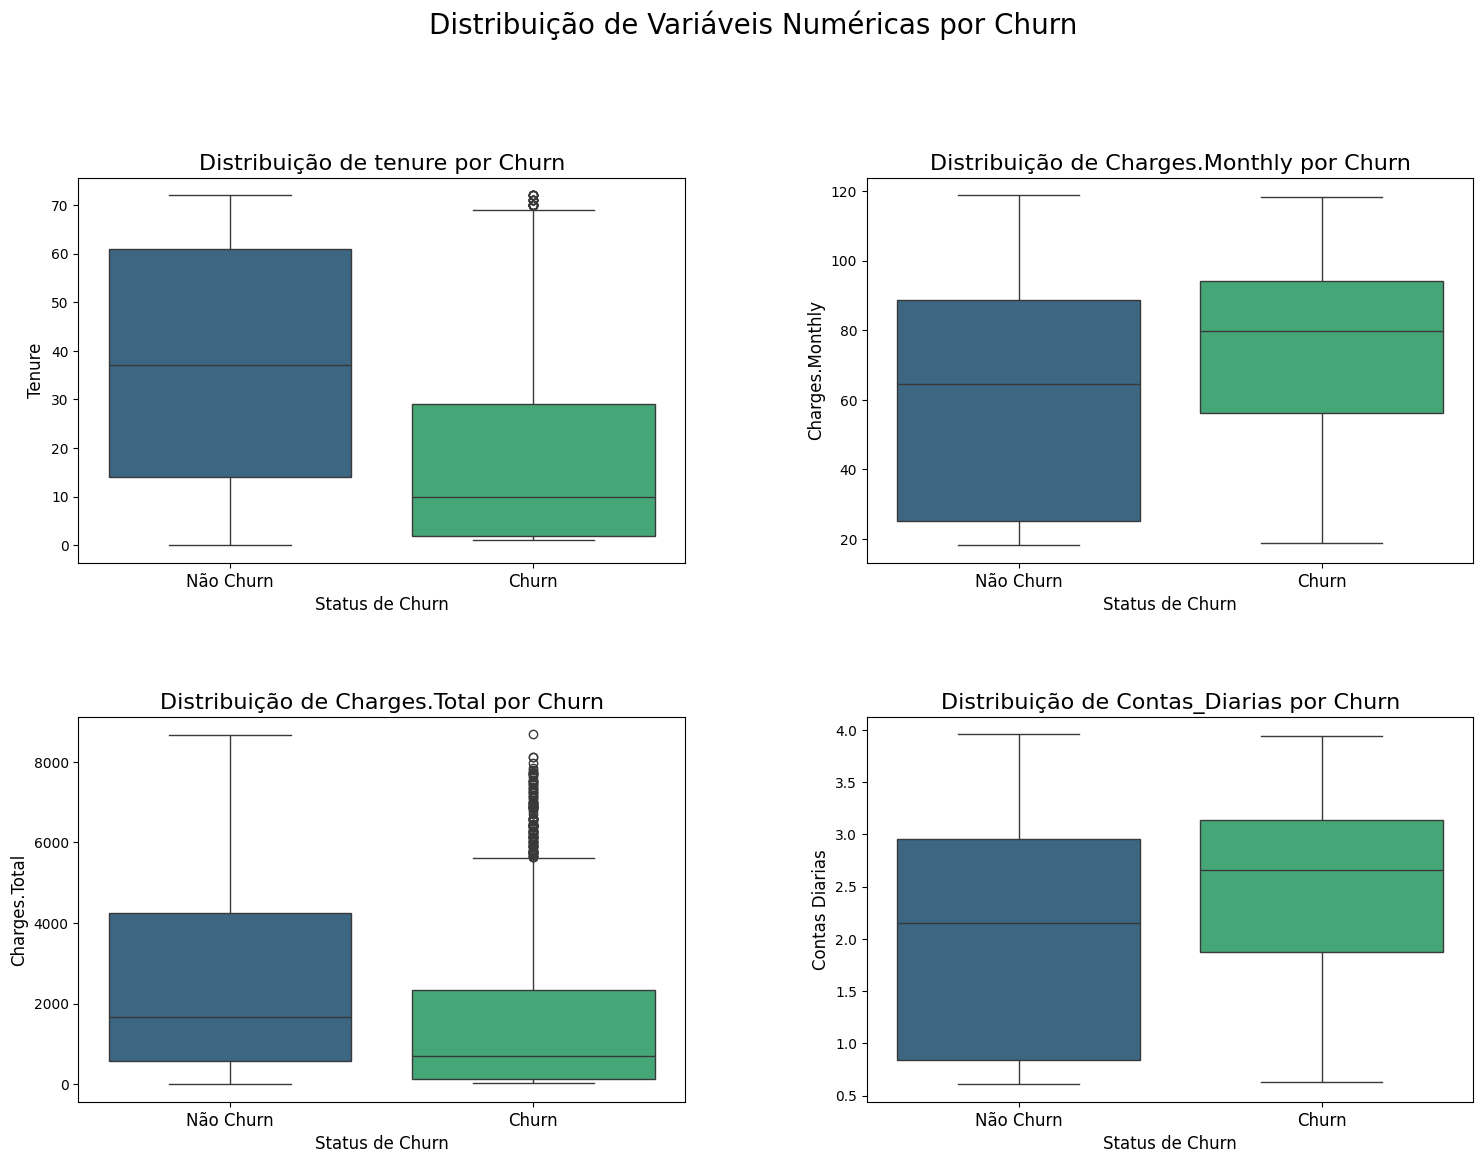

In [245]:
box_colunas_num = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias']

# Aumenta o tamanho da figura e adiciona um padding maior entre os subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
fig.suptitle('Distribuição de Variáveis Numéricas por Churn', fontsize=20, y=1.02) # Título geral da figura

# O flatten() transforma a matriz 'axes' em um array 1D para facilitar a iteração
axes = axes.flatten()

for i, col in enumerate(box_colunas_num):
    current_ax = axes[i]
    sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)

    current_ax.set_title(f'Distribuição de {col} por Churn', fontsize=16) # Título do subplot
    current_ax.set_xlabel('Status de Churn', fontsize=12) # Rótulo do eixo X mais genérico
    current_ax.set_ylabel(col.replace('_', ' ').title(), fontsize=12) # Rótulo do eixo Y formatado
    current_ax.set_xticklabels(['Não Churn', 'Churn'], fontsize=12) # Rótulos claros para 0 e 1 do Churn
    current_ax.tick_params(axis='y', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo Y


plt.show()





Agora vamos anlisar as colunas categóricas

Vamos analisar as colunas de informações categóricas. Legenda para coluna GENDER: Female -> 0
Male -> 1 Para a coluna CONTRACT: Month-to-month -> 0
One year -> 1
Two year -> 2

In [246]:
# Lista de colunas categóricas para análise em relação ao CHURN
colunas_categoricas_analise = ['gender', 'Contract']

In [247]:
# gender: {0: 'Female', 1: 'Male'}
# Contract: {0: 'One year', 1: 'Month-to-month', 2: 'Two year'}
mapeamento_genero_reverso = {0: 'Feminino', 1: 'Masculino'}
mapeamento_contrato_reverso = {0: 'Um Ano', 1: 'Mês a Mês', 2: 'Dois Anos'}



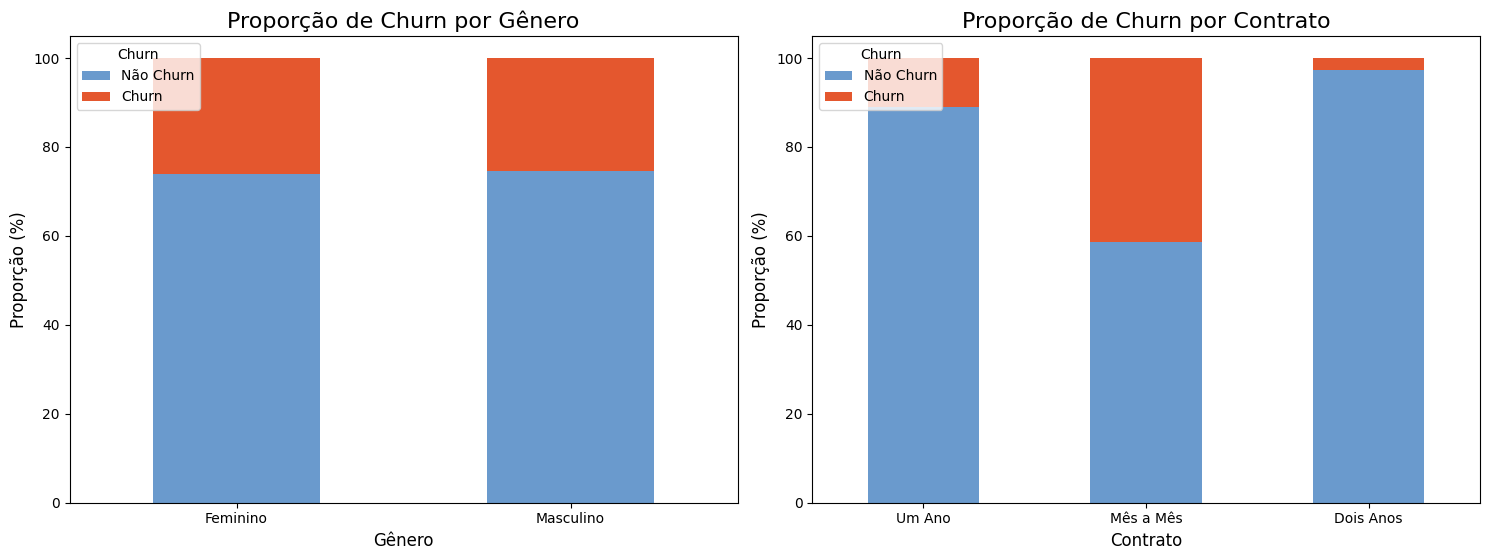

In [248]:
# Cria uma figura e eixos para os gráficos
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6)) # Uma linha, duas colunas
axes = axes.flatten() # Aplanar para facilitar a iteração

# Loop para plotar cada variável categórica
for i, col in enumerate(colunas_categoricas_analise):
    current_ax = axes[i]
    # Cria uma tabela de contingência, normalizando para proporção por categoria da coluna
    churn_categoria = pd.crosstab(dados[col], dados['Churn'], normalize='index') * 100

    # *** INÍCIO DA MODIFICAÇÃO CHAVE: APLICAÇÃO DOS RÓTULOS DESEJADOS ***
    # Renomear os índices para clareza, usando os mapeamentos reversos corretos
    # ISSO SÓ AFETA O ÍNDICE DA TABELA 'churn_categoria' TEMPORARIAMENTE PARA O PLOT
    if col == 'gender':
        churn_categoria.index = churn_categoria.index.map(mapeamento_genero_reverso)
    elif col == 'Contract':
        churn_categoria.index = churn_categoria.index.map(mapeamento_contrato_reverso)
    # *** FIM DA MODIFICAÇÃO CHAVE ***

    # Esta é a linha que faz a plotagem, usando os rótulos já traduzidos no índice
    churn_categoria.plot(kind='bar', stacked=True, ax=current_ax, color=cores_personalizadas_churn)


    # Definir títulos e rótulos com nomes em português
    titulo_coluna = col # Pega o nome original da coluna
    if col == 'gender':
        titulo_coluna_formatado = 'Gênero'
    elif col == 'Contract':
        titulo_coluna_formatado = 'Contrato'
    # Adicione mais conforme precisar para futuros gráficos
    else:
        titulo_coluna_formatado = titulo_coluna.replace("_", " ").title() # Fallback para outros nomes

    current_ax.set_title(f'Proporção de Churn por {titulo_coluna_formatado}', fontsize=16)
    current_ax.set_xlabel(titulo_coluna_formatado, fontsize=12)
    current_ax.set_ylabel('Proporção (%)', fontsize=12)
    current_ax.tick_params(axis='x', rotation=0, labelsize=10)
    current_ax.tick_params(axis='y', labelsize=10)

    current_ax.legend(title='Churn', labels=['Não Churn', 'Churn'], loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


 Análise Bivariada: Variáveis Numéricas vs. Churn (Box Plots)

<ipython-input-253-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-input-253-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-input-253-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-i

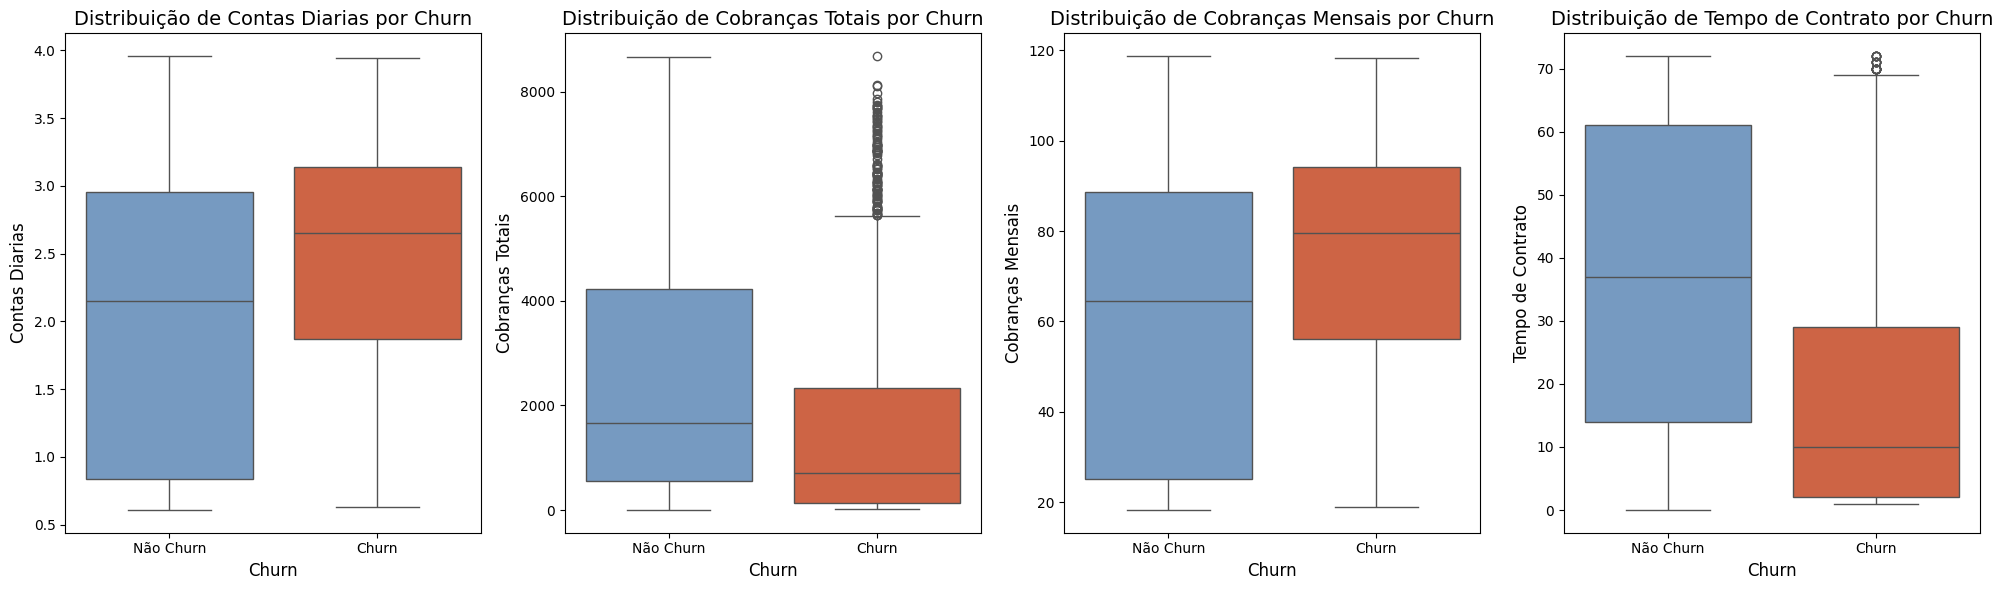

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assegure que 'dados' já foi carregado e pré-processado nas células anteriores
# 'dados' deve conter 'Churn' (como 0/1) e as colunas numéricas como 'Contas_diarias', 'Charges.Total', 'Charges.Monthly', 'tenure'.


colunas_numericas_analise = ['Contas_Diarias', 'Charges.Total', 'Charges.Monthly', 'tenure']

# Mapeamento para os rótulos do Churn no gráfico
mapeamento_churn_reverso = {0: 'Não Churn', 1: 'Churn'}

# Cores personalizadas (Não Churn / Churn)
cores_personalizadas_churn_box = ['#6a9acd', '#e4572e'] # Azul para Não Churn, Laranja/Vermelho para Churn

# Cria uma figura e eixos para os gráficos
# Uma linha, com uma coluna para cada variável numérica
fig, axes = plt.subplots(nrows=1, ncols=len(colunas_numericas_analise), figsize=(5 * len(colunas_numericas_analise), 6))
axes = axes.flatten() # Aplanar para facilitar a iteração se for apenas uma linha

for i, col in enumerate(colunas_numericas_analise):
    current_ax = axes[i]

    # Cria uma cópia temporária do DataFrame e adiciona uma coluna com os rótulos de texto de Churn
    dados_temp = dados.copy()
    dados_temp['Churn_Label'] = dados_temp['Churn'].map(mapeamento_churn_reverso)

    # Cria o box plot
    sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)

    # Definir títulos e rótulos
    titulo_coluna_formatado = col.replace("_", " ").title() # Default para capitalizar e substituir '_'

    # Ajusta o título e rótulo para os nomes em português específicos
    if col == 'Charges.Total':
        titulo_coluna_formatado = 'Cobranças Totais'
    elif col == 'Charges.Monthly':
        titulo_coluna_formatado = 'Cobranças Mensais'
    elif col == 'contas_diarias':
        titulo_coluna_formatado = 'Contas Diárias'
    elif col == 'tenure':
        titulo_coluna_formatado = 'Tempo de Contrato'

    current_ax.set_title(f'Distribuição de {titulo_coluna_formatado} por Churn', fontsize=14)
    current_ax.set_xlabel('Churn', fontsize=12) # O rótulo do eixo X já será 'Não Churn'/'Churn'
    current_ax.set_ylabel(titulo_coluna_formatado, fontsize=12)
    current_ax.tick_params(axis='x', rotation=0, labelsize=10)
    current_ax.tick_params(axis='y', labelsize=10)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

Gerando a Matriz de Correlação

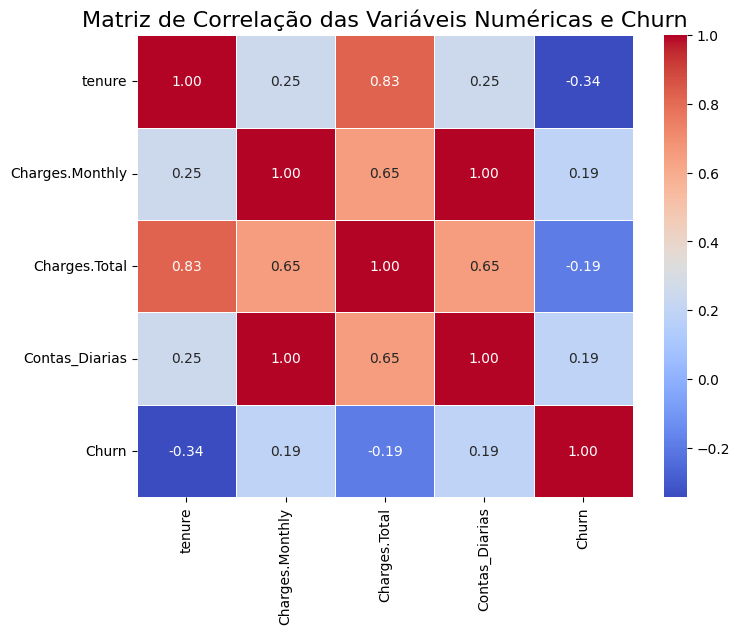

In [255]:
# Colunas numéricas para a matriz de correlação (Certifique-se de que todas existem no seu DataFrame 'dados')
colunas_para_correlacao = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias', 'Churn']

# Calcula a matriz de correlação
# O .corr() funcionará bem porque 'Churn' foi mapeado para 0 e 1.
matriz_correlacao = dados[colunas_para_correlacao].corr()

# Plota o heatmap da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas e Churn', fontsize=16)
plt.show()